In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
def frameBuilder(path="./live-data", kind=None):
    """Load every trade CSV in `path` into one frame.

    Handles both schemas. Live CSVs repeat their header once per file, so they
    are read against header.csv with the embedded header skipped; dry CSVs are
    self-describing. Dry columns are renamed to the live names and the
    live-only columns are filled in, so every cell below works on either source.

    kind: "live" | "dry", or None to auto-detect from the first file's header.
    """
    files = sorted(Path(path).glob("trade-07-2*.csv"))
    if not files:
        raise FileNotFoundError(f"no trade*.csv in {path}")
    if kind is None:
        kind = "dry" if "entry_ask" in pd.read_csv(files[0], nrows=0).columns else "live"

    if kind == "live":
        cols = pd.read_csv("header.csv").columns.tolist()
        df = pd.concat(
            (pd.read_csv(f, skiprows=1, header=None, names=cols) for f in files),
            ignore_index=True)
    else:
        df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)
        df = df.rename(columns={"entry_ask": "intended_ask", "pnl": "realized_pnl"})
        # Dry posts nothing and has no sizing, so fill in the live-only columns
        # the cells below reach for. A dry "share" risks its ask, so the ask
        # doubles as the notional. period_of_day is UTC here, local in live.
        df["post_error"] = np.nan
        df["notional_target"] = df.intended_ask
        df["period_of_day"] = df.window_start_ts % 86400 // 300

    # Traders built before 2026-07-27 re-logged a window on every failed
    # rollover retry (one live window landed 549 times, and a stuck row is
    # always a win, so the raw files overstate win rate). Key on
    # (window, side): one row per triggered side is legitimate, a repeat is not.
    dupes = df.duplicated(subset=["window_start_ts", "side"]).sum()
    if dupes:
        print(f"# duplicate rows: {dupes} (dropped)")
        df = df.drop_duplicates(subset=["window_start_ts", "side"])

    df["kind"] = kind
    # Normalized so live (dollars on notional) and dry (per share, risking the
    # ask) can be compared on the same axis.
    df["pnl_per_dollar"] = df.realized_pnl / df.notional_target
    return df.sort_values("window_start_ts").reset_index(drop=True)


live: 293 trades
# errors: 43
Pnl per $ risked: -3.743
Optimal entry: 82
Entries: 18; wins: 18; losses: 0; pnl per $: 0.296 


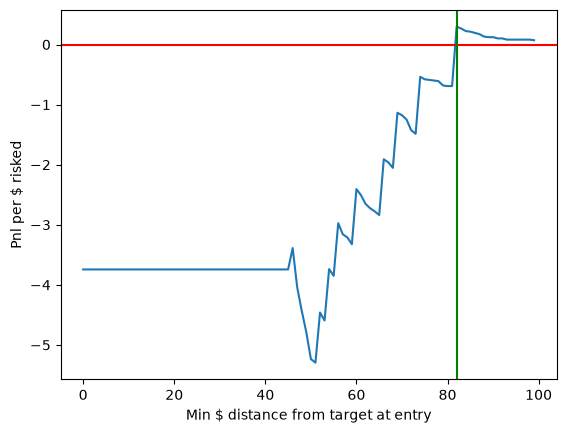

In [15]:
SOURCE = "./live-data"       # "./dry-data" or "./live-data"

df = frameBuilder(SOURCE)
pre = len(df)
df = df[df.post_error.isna()]

print(f"{df.kind.iloc[0]}: {len(df)} trades")
print(f"# errors: {pre - len(df)}")
print(f"Pnl per $ risked: {df.pnl_per_dollar.sum():.3f}")

fig = plt.figure()
x = np.arange(0,100)
y = np.zeros(100)
for i in range(100):
    y[i] = df[abs(df.price_diff_from_entry)>=x[i]].pnl_per_dollar.sum()
optimal_entry = np.argmax(y)

plt.plot(x, y)
plt.axhline(y=0, color='r')
plt.axvline(x=optimal_entry, color='g')
plt.xlabel("Min $ distance from target at entry")
plt.ylabel("Pnl per $ risked")


print(f"Optimal entry: {optimal_entry}")
optimal = df[abs(df.price_diff_from_entry) >= optimal_entry]
print(f"Entries: {len(optimal)}; wins: {len(optimal[optimal.won==1])}; losses: {len(optimal[optimal.won==0])}; pnl per $: {optimal.pnl_per_dollar.sum():.3f} ")


In [ ]:
# What went wrong
losses = df[df.won == 0]

# Live and dry carry different column sets, so show whichever this frame has
# rather than dumping all 20-odd columns.
cols = [c for c in ["window_start_ts", "side", "intended_ask", "entry_offset_s",
                    "swing_at_entry", "btc_at_entry", "target_pyth", "final_pyth",
                    "price_diff_from_entry", "resolved_side", "realized_pnl"]
        if c in losses.columns]
display(losses[cols])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Period of day. period_of_day is a 5-minute index (0-287), so scale it to
# hours and pin the range -- with bins=24 on the raw index the bins straddle
# whatever span the data happens to cover instead of landing on hours.
# NOTE: live-trader stamps this in local time, dry in UTC (see frameBuilder).
ax[0].hist(losses.period_of_day * 5 / 60, bins=24, range=(0, 24), edgecolor='black')
ax[0].set_title(f"# Losses over Hours ({df.kind.iloc[0]})")
ax[0].set_ylabel("# Losses")
ax[0].set_xlabel("Hour (local for live, UTC for dry)")

# Entry offset vs distance from target. x is the offset, y is the distance --
# the axis labels used to be the other way round.
ax[1].scatter(losses.entry_offset_s, abs(losses.price_diff_from_entry))
ax[1].set_title("Entry offset vs price difference")
ax[1].set_xlabel("Entry offset (s into the window)")
ax[1].set_ylabel("$ Price difference from target")

fig.tight_layout()


In [ ]:
wins = df[df.won == 1]

fig, ax = plt.subplots(1, figsize=(7, 5))

ax.scatter(wins.entry_offset_s, abs(wins.price_diff_from_entry), color="r", alpha=0.4, label="wins")
ax.scatter(losses.entry_offset_s, abs(losses.price_diff_from_entry), alpha=0.8, label="losses")
ax.set_title(f"Entry offset vs price difference ({df.kind.iloc[0]})")
ax.set_xlabel("Entry offset (s into the window)")
ax.set_ylabel("$ Price difference from target")
ax.legend()
